In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv(r'/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv')

In [5]:
data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [16]:
data= data.drop_duplicates()
data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [10]:
data.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

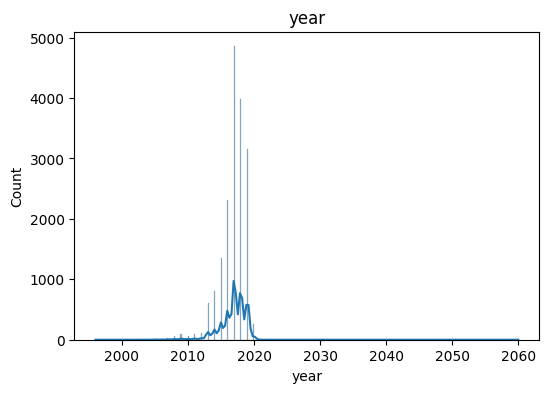

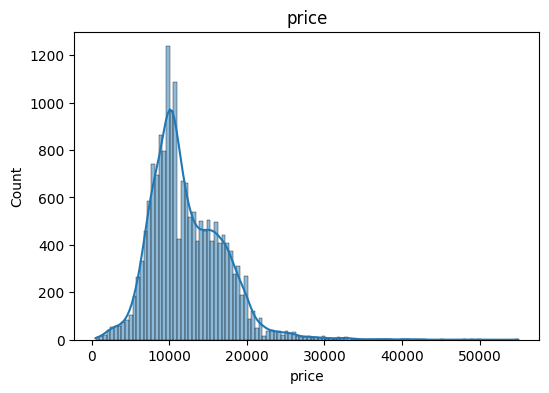

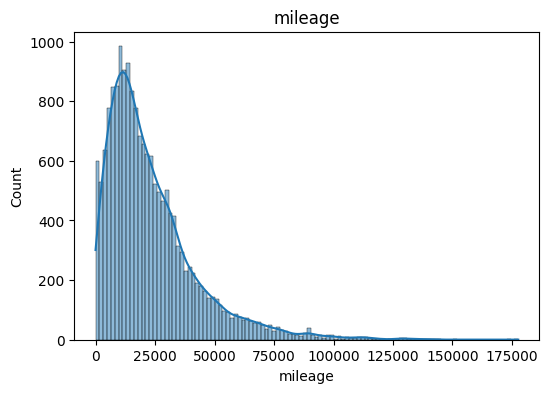

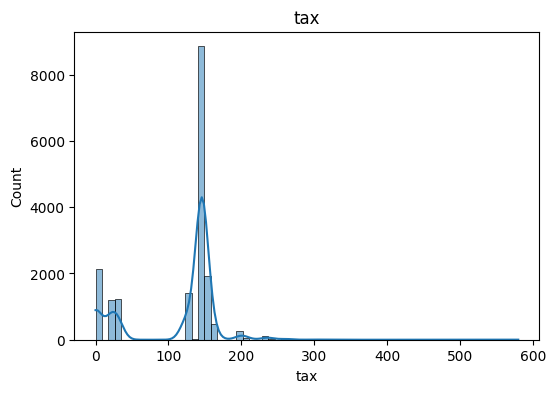

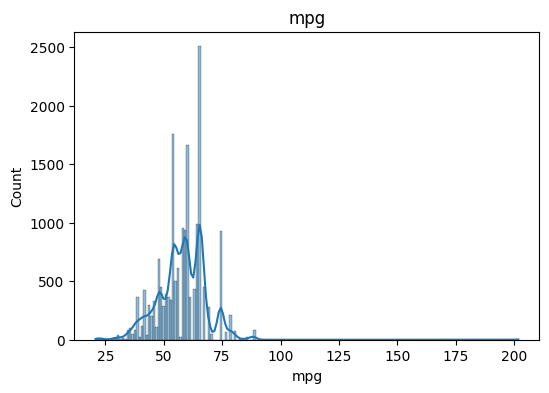

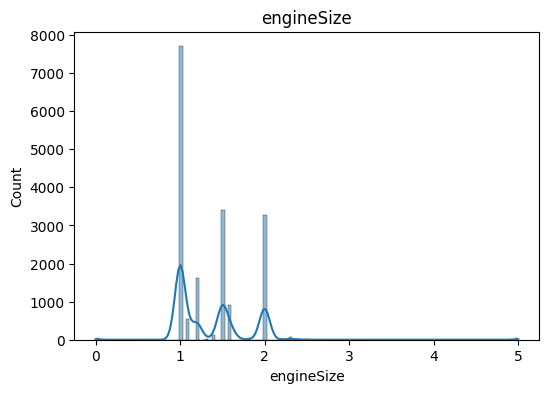

In [29]:
for col in data.select_dtypes(include = np.number).columns:
    plt.figure(figsize = (6,4))
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

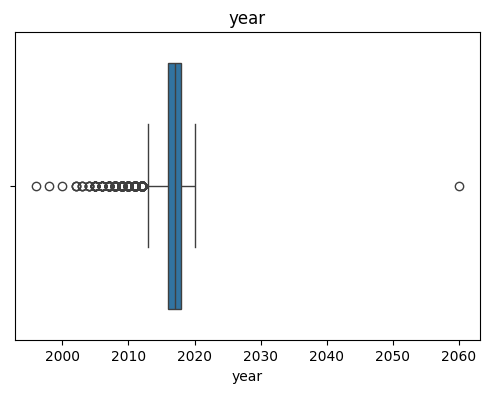

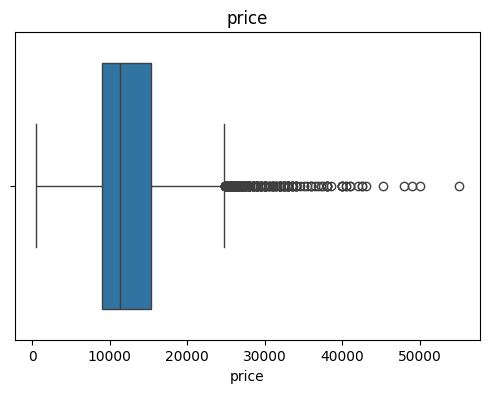

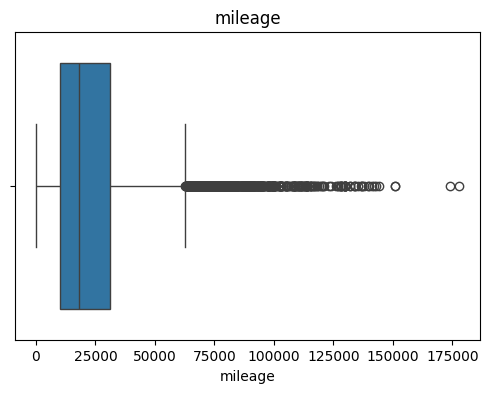

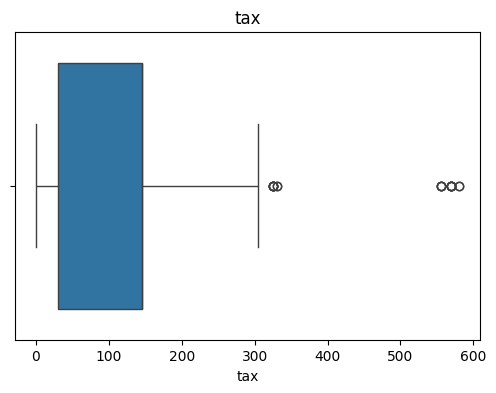

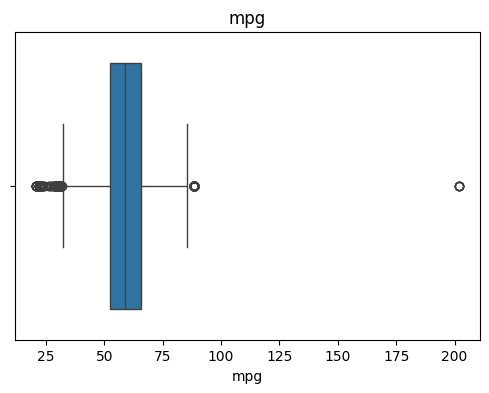

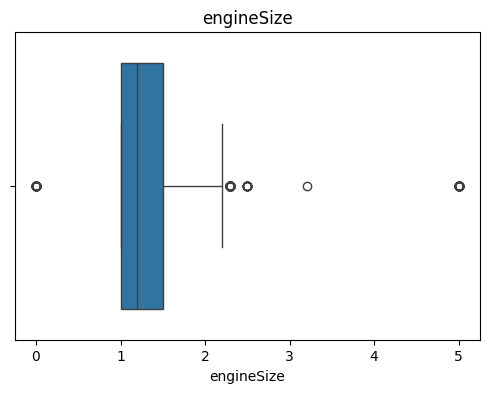

In [30]:
for col in data.select_dtypes(include = np.number).columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

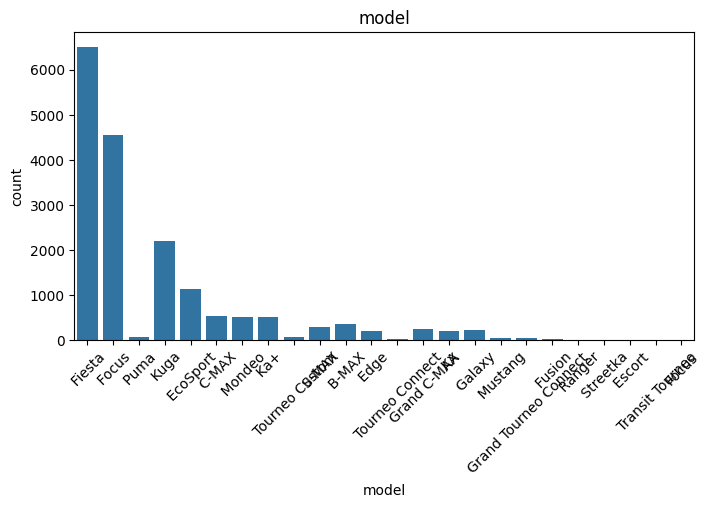

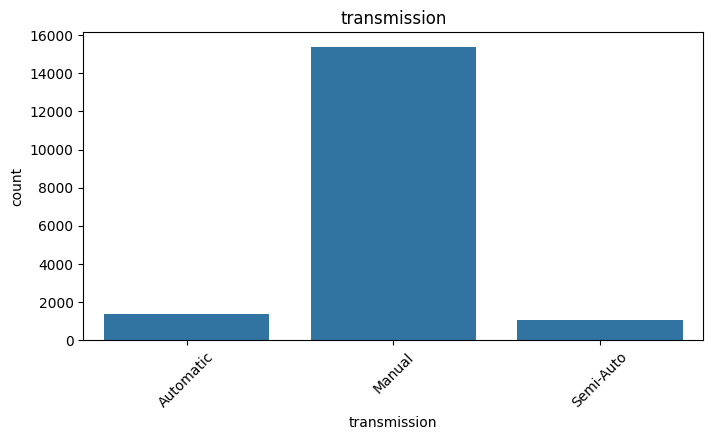

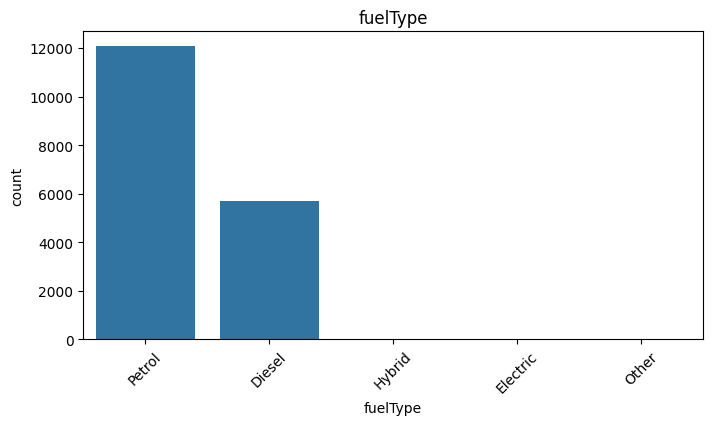

In [31]:
for col in data.select_dtypes(exclude = np.number).columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=data[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

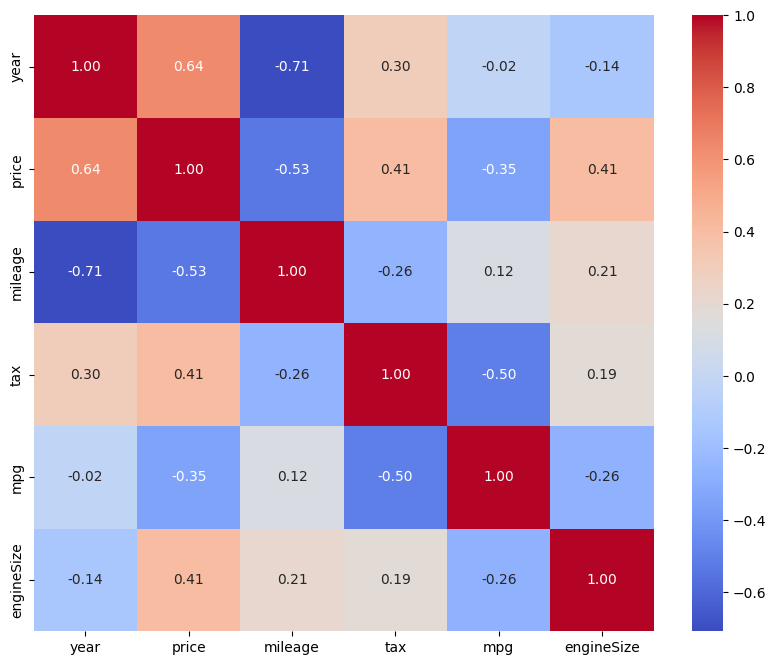

In [34]:
num_cols = data.select_dtypes(include = np.number).columns
corr  = data[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.show()

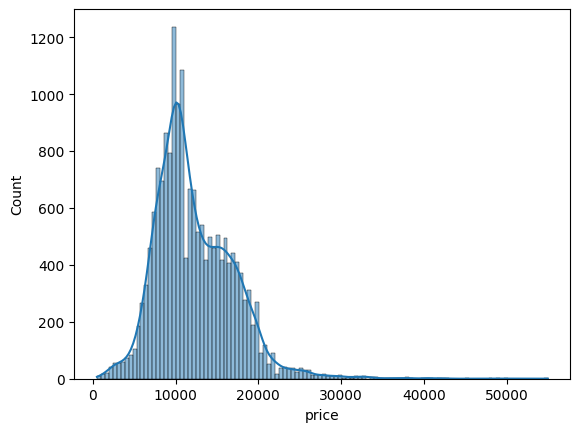

In [36]:
sns.histplot(data['price'], kde=True)
plt.show()

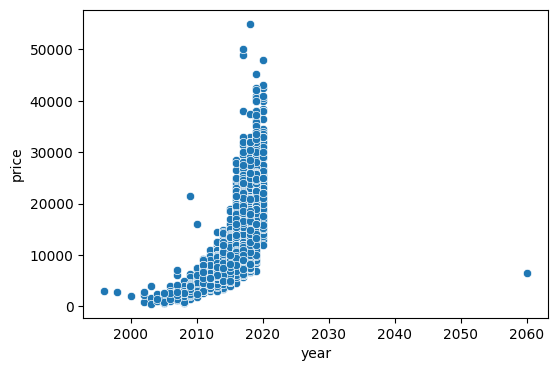

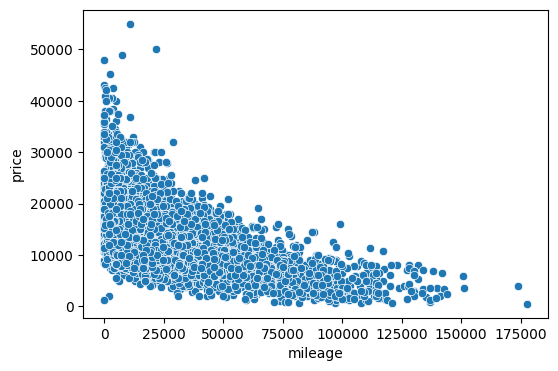

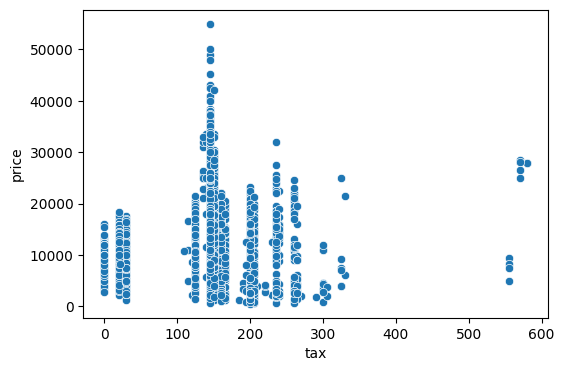

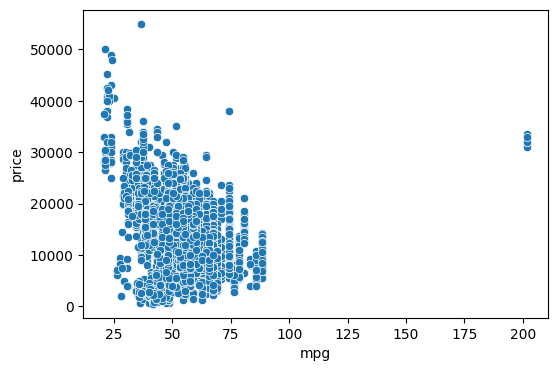

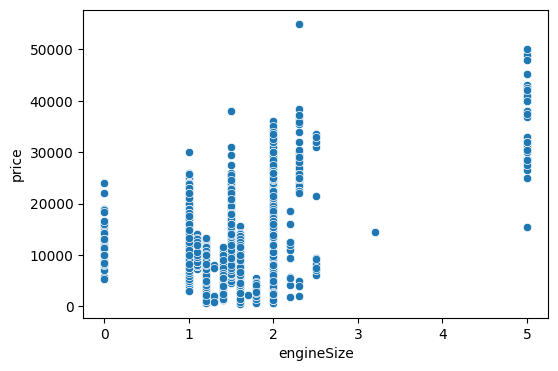

In [43]:
target = "price"
for col in num_cols:
    if col != target:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=data[col], y=data[target])
        plt.show()

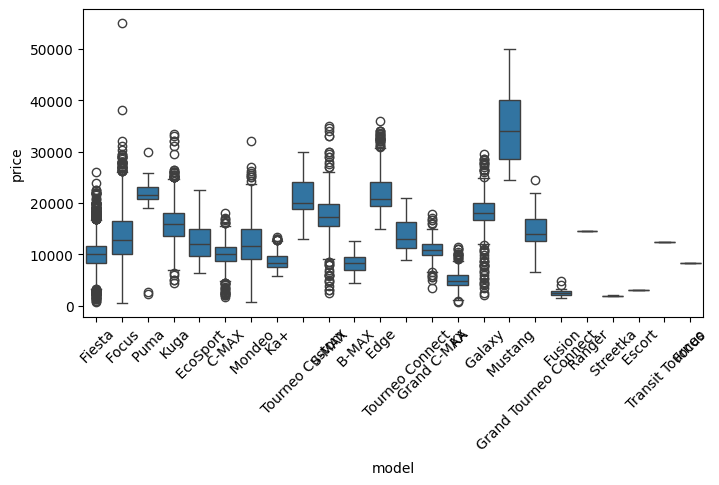

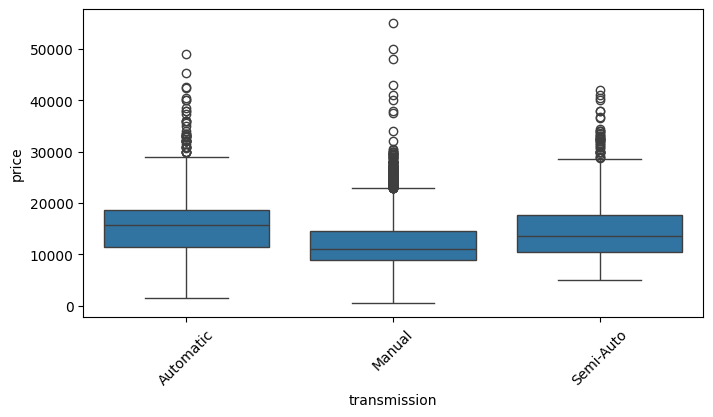

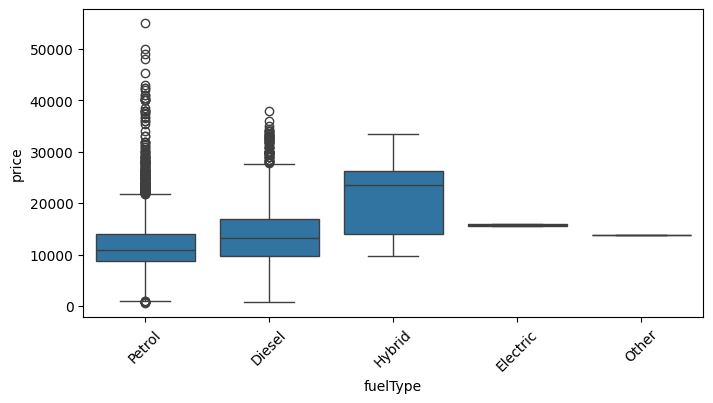

In [46]:
cat_cols = data.select_dtypes(exclude = np.number).columns
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=data[col], y=data[target])
    plt.xticks(rotation=45)
    plt.show()

In [48]:
X = data.drop('price' , axis = 1)
y = data['price']

In [49]:
X_encoded  = pd.get_dummies(X,drop_first=True)

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train , y_test = train_test_split(X_encoded , y , test_size = 0.2 , random_state = 42)

In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

model = LinearRegression()
model_lasso = Lasso(alpha = 0.1)

model.fit(X_train, y_train)
model_lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [65]:
y_pred = model.predict(X_test)
y_lasso_pred = model_lasso.predict(X_test)

In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mae_lasso = mean_absolute_error(y_test, y_lasso_pred)
mse = mean_squared_error(y_test, y_pred)
mse_lasso = mean_squared_error(y_test, y_lasso_pred)
rmse = mse ** 0.5
rmse = mse_lasso ** 0.5

r2 = r2_score(y_test, y_pred)
r2_lasso = r2_score(y_test , y_lasso_pred)

print("MAE :", mae)
print("MAE :", mae_lasso)
print("MSE :", mse)
print("MSE :", mse_lasso)
print("RMSE:", rmse)
print("R2 :", r2)
print('R2 :' , r2_lasso)

MAE : 1360.5433277571708
MAE : 1360.420602873655
MSE : 4060994.793946977
MSE : 4059196.5135138114
RMSE: 2014.7447762716279
R2 : 0.8188919779971244
R2 : 0.8189721758375015


In [67]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "predicted_lasso":y_lasso_pred
})

comparison.head()

,Actual,Predicted,predicted_lasso
9891,22975,22307.164026,22284.901889
13006,18000,15402.695067,15405.364960
15284,18500,16095.239751,16098.193743
6399,9985,11604.344993,11603.961232
8182,7998,11168.408105,11171.365283


In [72]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_encoded,
    y,
    cv=25,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.8705748  0.80147652 0.83661643 0.86635111 0.86886242 0.81153218
 0.83947772 0.84485811 0.85635177 0.84166531 0.84580827 0.829439
 0.85039311 0.84932658 0.86202887 0.84224973 0.76155152 0.81972277
 0.85912709 0.7879759  0.83346352 0.85058053 0.80682455 0.77256661
 0.67358041]
0.8272961940505243
